In [1]:
# 1) 라이브러리/상수/인증키 설정
import os
import time
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 발급받은 인증키(본인 키로 교체)
API_KEY = "my Seoul Key"

BASE_URL = "http://openapi.seoul.go.kr:8088"
SERVICE = "culturalEventInfo"  # 서비스명
FILE_TYPE = "json"             # 응답형식

if not API_KEY or API_KEY == "YOUR_SEOUL_OPENAPI_KEY":
    raise ValueError("API_KEY에 열린데이터광장에서 발급받은 인증키를 설정하세요.")

# 2) Requests를 사용한 데이터 수집(100건 이상)

"""
    1) API 호출 URL 구성
http://openapi.seoul.go.kr:8088/{api_key}/json/culturalEventInfo/{start}/{end}
"""
def build_url(api_key: str, start_idx: int, end_idx: int) -> str:
    return f"{BASE_URL}/{api_key}/{FILE_TYPE}/{SERVICE}/{start_idx}/{end_idx}"

"""
    2) 단일 페이지(row 범위) 데이터를 요청.
    응답에 {SERVICE: {..., RESULT:{CODE:...}, row:[...]}} 가 포함됨.
"""
def fetch_page(api_key: str, start_idx: int, end_idx: int, timeout: int = 20) -> dict:
    url = build_url(api_key, start_idx, end_idx)
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    data = resp.json()

    if SERVICE not in data:
        # 에러 응답일 경우 다른 키로 올 수 있어 방어적 처리
        raise RuntimeError(f"예상 필드({SERVICE})가 응답에 없습니다. 전체 키: {list(data.keys())[:5]}")

    block = data[SERVICE]
    result = block.get("RESULT", {})
    code = result.get("CODE", "")
    if code and code != "INFO-000":
        msg = result.get("MESSAGE", "")
        raise RuntimeError(f"API 오류 CODE={code}, MESSAGE={msg}")
    return block

"""
    3) 페이징으로 최소 min_records 이상을 수집.
"""
def fetch_cultural_events(api_key: str,
                          min_records: int = 300,   # 100보다 넉넉히
                          page_size: int = 200,     # 한 번에 가져올 행 개수
                          max_pages: int = 50,
                          sleep_sec: float = 0.2) -> list:
    all_rows = []
    # 첫 호출로 총건수 파악
    first_block = fetch_page(api_key, 1, 1)
    total = first_block.get("list_total_count", 0) or 0
    print(f"[INFO] 총 데이터 건수: {total:,}")

    pages = 0
    start = 1
    while pages < max_pages and len(all_rows) < min_records and start <= total:
        end = min(start + page_size - 1, total)
        block = fetch_page(api_key, start, end)
        rows = block.get("row", [])
        all_rows.extend(rows)
        pages += 1
        print(f"[INFO] 수집 누적: {len(all_rows):,}건 (요청구간 {start}~{end})")
        start = end + 1
        time.sleep(sleep_sec)  # 과도한 연속호출 예방
    return all_rows

# 실제 수집 실행
raw_rows = fetch_cultural_events(API_KEY, min_records=300, page_size=200)
print(f"[DONE] 최종 수집 건수: {len(raw_rows):,}건")


# 3) ETL 구현
#    - Extract: 위에서 JSON 추출 완료
#    - Transform: 필드 선택/타입 변환/이상치 처리
#    - Load: DataFrame 적재 & CSV 저장

# 사용할 필드
use_cols = [
    "CODENAME", "GUNAME", "TITLE", "DATE", "PLACE", "ORG_NAME",
    "USE_TRGT", "USE_FEE", "PLAYER", "PROGRAM", "ETC_DESC",
    "ORG_LINK", "MAIN_IMG", "RGSTDATE", "TICKET",
    "STRTDATE", "END_DATE", "THEMECODE", "LOT", "LAT", "IS_FREE", "HMPG_ADDR"
]

df = pd.DataFrame(raw_rows)
df = df[[c for c in use_cols if c in df.columns]].copy()

# 날짜형 변환
for col in ["STRTDATE", "END_DATE", "RGSTDATE"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# 숫자형 변환 (LOT=위도, LAT=경도)
for col in ["LOT", "LAT"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 무료여부: 문자열 -> 불리언
if "IS_FREE" in df.columns:
    df["무료여부"] = df["IS_FREE"].astype(str).str.contains("무료", case=False, na=False)
else:
    df["무료여부"] = np.nan

# 기간(일수)
if {"STRTDATE", "END_DATE"}.issubset(df.columns):
    df["기간_일수"] = (df["END_DATE"] - df["STRTDATE"]).dt.days + 1
else:
    df["기간_일수"] = np.nan

# 결측 대체
if "GUNAME" in df.columns:
    df["GUNAME"] = df["GUNAME"].fillna("미정")
if "CODENAME" in df.columns:
    df["CODENAME"] = df["CODENAME"].fillna("기타")

# 이상치 처리(선택)
# (1) 좌표 유효 범위(대한민국): 위도 LOT [33, 39], 경도 LAT [124, 132]
if {"LOT", "LAT"}.issubset(df.columns):
    coord_mask = (
        (df["LOT"].between(33, 39, inclusive="both")) &
        (df["LAT"].between(124, 132, inclusive="both"))
    )
    df.loc[~coord_mask, ["LOT", "LAT"]] = np.nan

# (2) 180일 초과 장기 기간 표시
df["기간_과다"] = df["기간_일수"].fillna(-1) > 180

# (3) 중복 제거: (TITLE, STRTDATE, PLACE) 기준
subset_cols = [c for c in ["TITLE", "STRTDATE", "PLACE"] if c in df.columns]
if subset_cols:
    before = len(df)
    df = df.drop_duplicates(subset=subset_cols)
    after = len(df)
    print(f"[INFO] 중복 제거: {before - after}건 제거 → {after}건 남음")

# 파생: 월
df["월"] = df["STRTDATE"].dt.month

# CSV 저장
csv_path = "/content/seoul_cultural_events.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"[DONE] CSV 저장: {csv_path} (행 수={len(df):,})")

[INFO] 총 데이터 건수: 4,583
[INFO] 수집 누적: 200건 (요청구간 1~200)
[INFO] 수집 누적: 400건 (요청구간 201~400)
[DONE] 최종 수집 건수: 400건
[INFO] 중복 제거: 0건 제거 → 400건 남음
[DONE] CSV 저장: /content/seoul_cultural_events.csv (행 수=400)


/tmp/ipython-input-824909847.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gu_eng.index, y=top_gu_eng.values, palette="viridis")


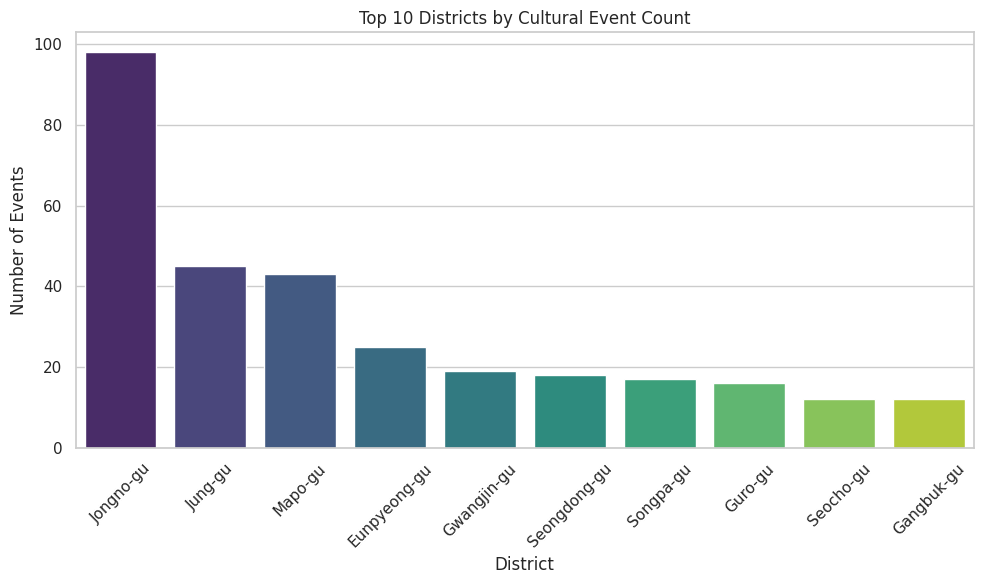

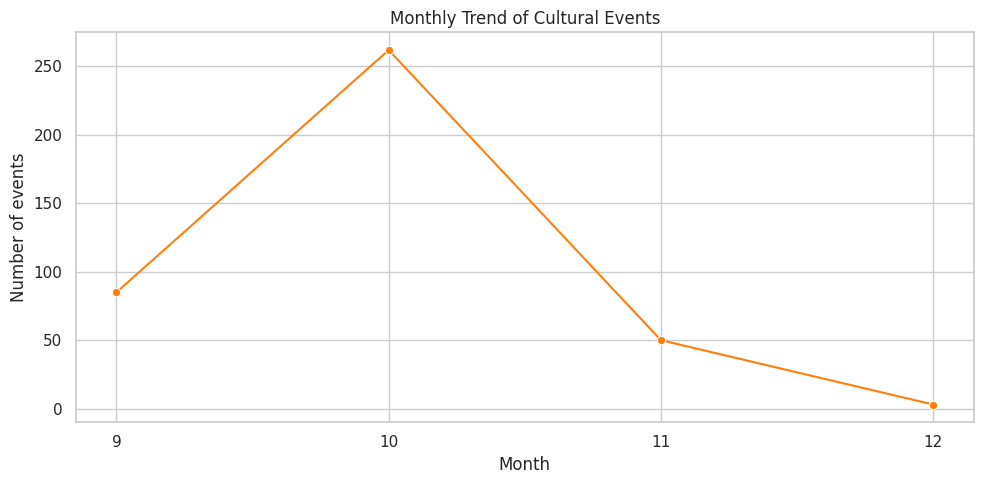

/tmp/ipython-input-824909847.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=["#2ca02c", "#d62728"])


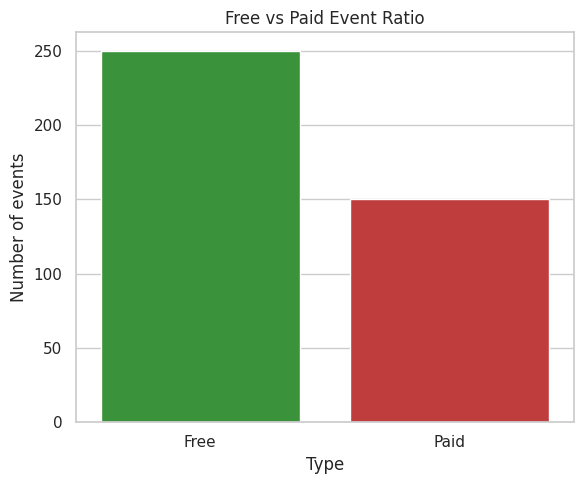

In [8]:
# 4) 시각화

import matplotlib.pyplot as plt
import string

#=================================================================
# 폰트
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid")

# 그래프에서 한글폰트 깨짐 문제: 영어 표기로 해결
# 자치구 한글 -> 영문으로 바꾸기
district_map = {
    "종로구": "Jongno-gu",
    "중구": "Jung-gu",
    "용산구": "Yongsan-gu",
    "성동구": "Seongdong-gu",
    "광진구": "Gwangjin-gu",
    "동대문구": "Dongdaemun-gu",
    "중랑구": "Jungnang-gu",
    "성북구": "Seongbuk-gu",
    "강북구": "Gangbuk-gu",
    "도봉구": "Dobong-gu",
    "노원구": "Nowon-gu",
    "은평구": "Eunpyeong-gu",
    "서대문구": "Seodaemun-gu",
    "마포구": "Mapo-gu",
    "양천구": "Yangcheon-gu",
    "강서구": "Gangseo-gu",
    "구로구": "Guro-gu",
    "금천구": "Geumcheon-gu",
    "영등포구": "Yeongdeungpo-gu",
    "동작구": "Dongjak-gu",
    "관악구": "Gwanak-gu",
    "서초구": "Seocho-gu",
    "강남구": "Gangnam-gu",
    "송파구": "Songpa-gu",
    "강동구": "Gangdong-gu",
}

# 1) 한글 자치구 -> 영어 라벨로 변환
df["District_Eng"] = df["GUNAME"].map(district_map)

# 1-1) 매핑 실패(미정/오탈자) 처리: 영어 라벨이 비었으면 'Unknown'으로
df["District_Eng"] = df["District_Eng"].fillna("Unknown")

# 2) Top 10 by count (영어 라벨 기준 집계)
top_gu_eng = df["District_Eng"].value_counts().head(10)

#=================================================================

# (그래프 1) 문화행사수가 많은 자치구 Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x=top_gu_eng.index, y=top_gu_eng.values, palette="viridis")
plt.title("Top 10 Districts by Cultural Event Count")
plt.xlabel("District")  # 자치구
plt.ylabel("Number of Events")  # 행사 수
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("문화행사수가 많은 자치구 Top 10.png", dpi=150)
plt.show()
print()

# (그래프 2) 월별 문화행사 수 추이
plt.figure(figsize=(10, 5))
month_counts = df["월"].value_counts().sort_index()
sns.lineplot(x=month_counts.index, y=month_counts.values, marker="o", color="#ff7f0e")
plt.title("Monthly Trend of Cultural Events")
plt.xlabel("Month")  # 월
plt.ylabel("Number of events")  # 행사 수
plt.xticks(range(9, 13))
plt.xticks(month_counts.index)
plt.tight_layout()
#plt.savefig("월별 문화행사 수 추이.png", dpi=150)
plt.show()
print()

# (그래프 3) 무료/유료 비율
plt.figure(figsize=(6, 5))
fee_counts = df["무료여부"].value_counts(dropna=False)
labels = ["Free", "Paid"]
sizes = [fee_counts.get(True, 0), fee_counts.get(False, 0)]
# 모두 NaN이면 정보없음 하나로 표시
if sum(sizes) == 0:
    labels = ["정보없음"]
    sizes = [fee_counts.get(np.nan, 0)]
sns.barplot(x=labels, y=sizes, palette=["#2ca02c", "#d62728"])
plt.title("Free vs Paid Event Ratio")
plt.xlabel("Type")  # 구분
plt.ylabel("Number of events")  # 행사 수
plt.tight_layout()
#plt.savefig("유무료비율.png", dpi=150)
plt.show()